<a href="https://colab.research.google.com/github/umagujjula/customer-churn/blob/main/Customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
# PROBLEM STATEMENT , BUSINESS UNDERSTANDING

***Predict whether a customer will churn (leave) or not churn, based on their past behavior and service usage***

------------------------------------------------------------

***Customer churn refers to the situation where customers stop using a company’s product or service.***

----------------------------------------------------------------

***In competitive industries such as telecom, banking, subscription-based services, and e-commerce, acquiring a new customer is significantly more expensive than retaining an existing one.***

------------------------------------------------------------------

*****The business wants to:*****


      Identify customers who are likely to churn

      Understand key factors influencing churn
      
      Take proactive retention actions (offers, discounts, better support)***

********By predicting churn in advance, the company can:********



     1. Reduce revenue loss

     2. Improve customer satisfaction

    3. Increase customer lifetime value

    4. Optimize marketing and retention costs

In [117]:
#  IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [118]:
# DATA LOADING

In [119]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df = df.drop(columns = ['TotalCharges'],axis=1)
df = df.drop(columns = ['MonthlyCharges','MultipleLines','Dependents','InternetService','DeviceProtection','StreamingTV','StreamingMovies','OnlineSecurity','OnlineBackup','TechSupport'],axis=1)
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,Churn
2624,0820-FNRNX,Male,0,Yes,17,Yes,Month-to-month,Yes,Mailed check,No
2420,3694-DELSO,Male,0,Yes,4,No,Month-to-month,No,Credit card (automatic),No
214,2504-DSHIH,Male,1,Yes,23,Yes,Month-to-month,No,Electronic check,No
3000,7613-LLQFO,Male,0,No,12,Yes,Month-to-month,Yes,Electronic check,Yes
3366,1855-AGAWH,Male,0,Yes,31,Yes,One year,Yes,Electronic check,No
2857,7771-CFQRQ,Female,0,Yes,47,Yes,Two year,No,Bank transfer (automatic),No
712,9661-JALZV,Female,0,No,58,Yes,Two year,Yes,Credit card (automatic),No
1506,8819-WFGGJ,Male,0,Yes,68,No,Two year,Yes,Bank transfer (automatic),No
4991,1502-XFCVR,Female,0,No,58,Yes,One year,Yes,Electronic check,Yes
5610,1320-HTRDR,Female,0,No,3,Yes,Month-to-month,Yes,Electronic check,Yes


In [120]:
df.shape

(7043, 10)

In [121]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
tenure,0
PhoneService,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
Churn,0


****There is no null values in the data.****

In [122]:
df = df.drop(['customerID'],axis=1)


In [123]:
df.head()

,gender,SeniorCitizen,Partner,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,1,No,Month-to-month,Yes,Electronic check,No
1,Male,0,No,34,Yes,One year,No,Mailed check,No
2,Male,0,No,2,Yes,Month-to-month,Yes,Mailed check,Yes
3,Male,0,No,45,No,One year,No,Bank transfer (automatic),No
4,Female,0,No,2,Yes,Month-to-month,Yes,Electronic check,Yes


In [124]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [125]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [126]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


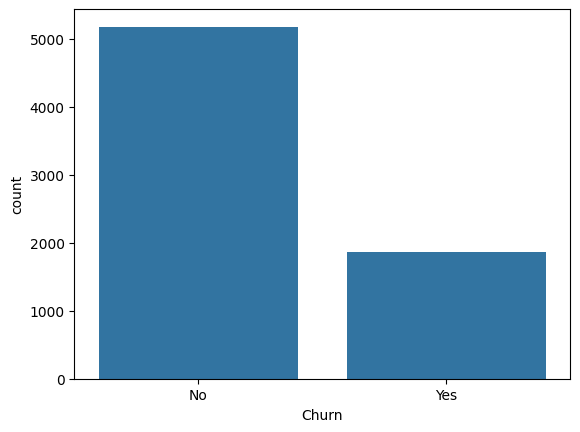

In [127]:
sns.countplot(x="Churn",data=df)

plt.show()

*****Report*****

     1. More number of customers stayed than churned

     2. The percentage is 73-26 .So the data is imbalanced data

     3. Churn is categorical (Yes/No)

In [128]:
#  DATA  DIVIDING

In [129]:
X = df.iloc[:,:-1]  # Independent

In [130]:
Y = df.iloc[:,-1]  #  Dependent

In [131]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [132]:
X_train.shape

(5634, 8)

In [133]:
X_test.shape

(1409, 8)

In [134]:
#  Dividing the data into numerical and categorical data

X_train_num = X_train.select_dtypes(exclude='object')
X_train_cat = X_train.select_dtypes(include='object')
X_test_num = X_test.select_dtypes(exclude='object')
X_test_cat = X_test.select_dtypes(include='object')

In [135]:
print(f"===========================================")
print(f"X_train_num columns are : {X_train_num.columns}")
print("============================================")
print(f"X_train_cat columns are : {X_train_cat.columns}")

print("==================================================")
print(f"X_test num columns are : {X_test_num.columns}")

print("====================================================")
print(f"X_test cat columns are : {X_test_cat.columns}")

X_train_num columns are : Index(['SeniorCitizen', 'tenure'], dtype='object')
X_train_cat columns are : Index(['gender', 'Partner', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod'],
      dtype='object')
X_test num columns are : Index(['SeniorCitizen', 'tenure'], dtype='object')
X_test cat columns are : Index(['gender', 'Partner', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod'],
      dtype='object')


In [136]:
#  VARIABLE  TRANSFORMATION
#  variable transformation is done on numerical columns
# In the vaiale transformaion ,there are lot of technques . Out of them yeojohnson technique wil give the best results

In [137]:
# Yeojohnson Technique

In [138]:
from scipy import stats

for i in X_train_num.columns:
  X_train_num[i + '_yeo'],alpha = stats.yeojohnson(X_train_num[i])
  X_test_num[i + '_yeo'],alpha = stats.yeojohnson(X_test_num[i])
  X_train_num = X_train_num.drop([i],axis=1)
  X_test_num = X_test_num.drop([i],axis=1)

In [139]:
print(f"Ater variable transformation X_train numerical column are : {X_train_num.columns}")

Ater variable transformation X_train numerical column are : Index(['SeniorCitizen_yeo', 'tenure_yeo'], dtype='object')


In [140]:
print(f"Ater variable transformation X_test numerical column are : {X_test_num.columns}")

Ater variable transformation X_test numerical column are : Index(['SeniorCitizen_yeo', 'tenure_yeo'], dtype='object')


*******Outliers Handling*******

In [141]:
#  Checking outlies present or not

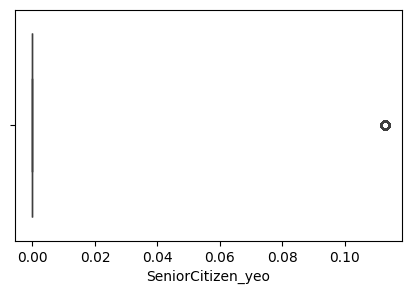

In [142]:
plt.figure(figsize=(5,3))

sns.boxplot(x=X_train_num['SeniorCitizen_yeo'])

plt.show()

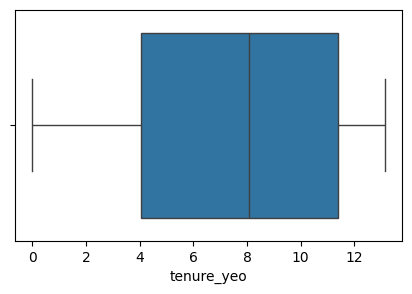

In [143]:
plt.figure(figsize=(5,3))

sns.boxplot(x=X_train_num['tenure_yeo'])

plt.show()

In [144]:
#  There is only 1 outlier in SeniorCitizen_yeo column and no outliers in tenure_yeo and monthlyCharges_yeo clumns

In [145]:
# Trimming method ---->one of the outlie solving method

In [146]:
for i in X_train_num.columns:
    iqr = X_train_num[i].quantile(0.75) - X_train_num[i].quantile(0.25)
    upper_limit = X_train_num[i].quantile(0.75) + 1.5 * iqr
    lower_limit = X_train_num[i].quantile(0.25) - 1.5 * iqr
    X_train_num[i + '_trim'] = np.where(X_train_num[i]>upper_limit,upper_limit,
                                                np.where(X_train_num[i]<lower_limit,lower_limit,X_train_num[i]))

    X_test_num[i + '_trim'] = np.where(X_test_num[i] > upper_limit, upper_limit,
                                                np.where(X_test_num[i] < lower_limit, lower_limit, X_test_num[i]))

    X_train_num = X_train_num.drop([i],axis=1)
    X_test_num = X_test_num.drop([i],axis=1)

In [147]:
print(f"Afer trimming method the columnns are : {X_train_num.columns}")

Afer trimming method the columnns are : Index(['SeniorCitizen_yeo_trim', 'tenure_yeo_trim'], dtype='object')


In [148]:
print(f"Afer trimming method the columnns are : {X_test_num.columns}")

Afer trimming method the columnns are : Index(['SeniorCitizen_yeo_trim', 'tenure_yeo_trim'], dtype='object')


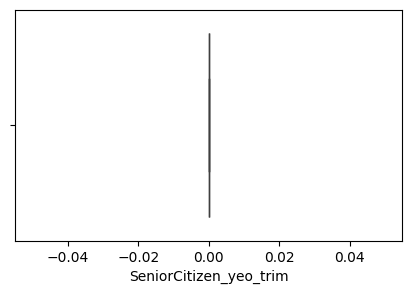

In [149]:
#  After trimming method

plt.figure(figsize=(5,3))

sns.boxplot(x=X_train_num['SeniorCitizen_yeo_trim'])

plt.show()

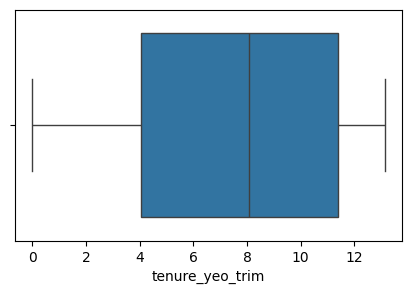

In [150]:
# After trimming method

plt.figure(figsize=(5,3))

sns.boxplot(x=X_train_num['tenure_yeo_trim'])

plt.show()

In [151]:
# Now there is no  outliers  in the data

*********Feature selection*********

In [152]:
# There are 3 techniqes for feature selection
#1. constant
# 2. Quasi constant
# 3. Hypothesis Testing

In [153]:
# Constant Technique

# Costant technique is used to remov the columns whosw variance is 0.0

In [154]:
print(f"Before constant technique the columns are : {X_train_num.columns}")

Before constant technique the columns are : Index(['SeniorCitizen_yeo_trim', 'tenure_yeo_trim'], dtype='object')


In [155]:
from sklearn.feature_selection import VarianceThreshold

constant_reg = VarianceThreshold(0.0)
constant_reg.fit(X_train_num)
best_columns_constant = X_train_num.columns[constant_reg.get_support()]
X_train_num = constant_reg.transform(X_train_num)
X_test_num = constant_reg.transform(X_test_num)

X_train_num = pd.DataFrame(X_train_num,columns=best_columns_constant)
X_test_num = pd.DataFrame(X_test_num,columns=best_columns_constant)

In [156]:
print(f"After constant technique the columns are : {X_train_num.columns}")

After constant technique the columns are : Index(['tenure_yeo_trim'], dtype='object')


In [157]:
print(f"After constant technique the columns are : {X_test_num.columns}")

After constant technique the columns are : Index(['tenure_yeo_trim'], dtype='object')


In [158]:
# 2. Quasi constant technique --> used to remove the columns whose variance is 0.1

In [159]:
Quasi_constant_reg = VarianceThreshold(0.1)
Quasi_constant_reg.fit(X_train_num)
best_columns_Quasi_constant = X_train_num.columns[Quasi_constant_reg.get_support()]
X_train_num = Quasi_constant_reg.transform(X_train_num)
X_test_num = Quasi_constant_reg.transform(X_test_num)

X_train_num = pd.DataFrame(X_train_num,columns=best_columns_Quasi_constant)

In [160]:
print(f"After Quasi constant the columns are : {X_train_num.columns}")

After Quasi constant the columns are : Index(['tenure_yeo_trim'], dtype='object')


In [161]:
# 3. Hypothesis testing

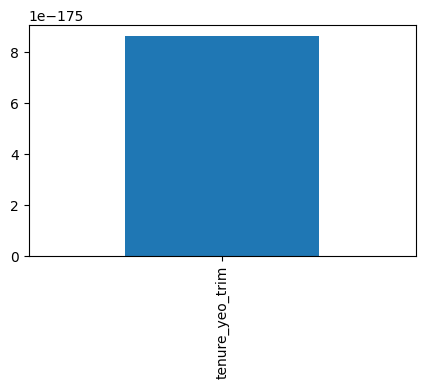

In [162]:
from scipy.stats import pearsonr

sample_Y_train = Y_train.copy()
sample_Y_train = sample_Y_train.map({'Yes':1,'No':0}).astype(int)
c = []
for i in X_train_num.columns:
    c.append(pearsonr(X_train_num[i],sample_Y_train))
c = np.array(c)
p_value = pd.Series(c[:, 1], index=X_train_num.columns)
p_value.sort_values(ascending=False, inplace=True)
plt.figure(figsize=(5,3))
p_value.plot.bar()
plt.show()

****Converting categorical data to numerical data****

In [163]:
X_train_cat

,gender,Partner,PhoneService,Contract,PaperlessBilling,PaymentMethod
2142,Female,No,Yes,One year,No,Mailed check
1623,Female,No,Yes,Two year,Yes,Bank transfer (automatic)
6074,Male,Yes,No,Month-to-month,Yes,Electronic check
1362,Male,No,Yes,Month-to-month,Yes,Electronic check
6754,Male,No,Yes,Two year,Yes,Bank transfer (automatic)
...,...,...,...,...,...,...
3772,Male,Yes,Yes,Month-to-month,Yes,Electronic check
5191,Female,Yes,Yes,Two year,Yes,Credit card (automatic)
5226,Male,Yes,Yes,Month-to-month,Yes,Electronic check
5390,Male,No,Yes,Month-to-month,Yes,Electronic check


In [164]:
# Since all the columns are nominal columns .So we are performing OneHotEncoder()


In [165]:
from sklearn.preprocessing import OneHotEncoder
one_hot = OneHotEncoder(drop='first')
one_hot.fit(X_train_cat[['gender','Partner','PhoneService','Contract','PaperlessBilling','PaymentMethod']])

OneHotEncoder(drop='first')

In [166]:
#  'MultipleLines','Dependents','InternetService','DeviceProtection','StreamingTV','StreamingMovies'

In [167]:
result1 = one_hot.transform(X_train_cat[['gender','Partner','PhoneService','Contract','PaperlessBilling','PaymentMethod']]).toarray()

In [168]:
print(result1)

[[0. 0. 1. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 1. 0.]
 ...
 [1. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 1. 0. 0.]]


In [169]:
#  'MultipleLines','Dependents','InternetService','DeviceProtection','StreamingTV','StreamingMovies'

In [170]:
result2 = one_hot.transform(X_test_cat[['gender','Partner','PhoneService','Contract','PaperlessBilling','PaymentMethod']]).toarray()

In [171]:
print(result2)

[[0. 1. 0. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 0. 0. 1.]
 ...
 [1. 1. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]]


In [172]:
one_hot.get_feature_names_out()

array(['gender_Male', 'Partner_Yes', 'PhoneService_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype=object)

In [173]:
f1 = pd.DataFrame(data=result1, columns=one_hot.get_feature_names_out())
f2 = pd.DataFrame(data=result2, columns=one_hot.get_feature_names_out())
X_train_cat.reset_index(drop=True, inplace=True)
f1.reset_index(drop=True, inplace=True)
X_test_cat.reset_index(drop=True, inplace=True)
f2.reset_index(drop=True, inplace=True)

In [174]:
#  'MultipleLines','Dependents','InternetService','DeviceProtection','StreamingTV','StreamingMovies'

In [175]:
X_train_cat = pd.concat([X_train_cat, f1], axis=1)
X_train_cat = X_train_cat.drop(['gender','Partner','PhoneService','Contract','PaperlessBilling','PaymentMethod'], axis=1)
X_test_cat = pd.concat([X_test_cat, f2], axis=1)
X_test_cat = X_test_cat.drop(['gender','Partner','PhoneService','Contract','PaperlessBilling','PaymentMethod'], axis=1)


In [176]:
print(f"X_train_cat columns ae : {X_train_cat.columns}")

X_train_cat columns ae : Index(['gender_Male', 'Partner_Yes', 'PhoneService_Yes', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [177]:
print(f"{X_train_cat.sample(3)}")

      gender_Male  Partner_Yes  PhoneService_Yes  Contract_One year  \
3458          0.0          0.0               1.0                0.0   
518           1.0          1.0               1.0                0.0   
80            0.0          0.0               1.0                1.0   

      Contract_Two year  PaperlessBilling_Yes  \
3458                0.0                   1.0   
518                 1.0                   0.0   
80                  0.0                   0.0   

      PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
3458                                    0.0                             0.0   
518                                     0.0                             0.0   
80                                      0.0                             0.0   

      PaymentMethod_Mailed check  
3458                         0.0  
518                          0.0  
80                           1.0  


In [178]:
print(f"X_test_cat columns ae : {X_test_cat.columns}")

X_test_cat columns ae : Index(['gender_Male', 'Partner_Yes', 'PhoneService_Yes', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [179]:
X_train_cat

,gender_Male,Partner_Yes,PhoneService_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
5629,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5630,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
5631,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5632,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [180]:
X_test_cat

,gender_Male,Partner_Yes,PhoneService_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1404,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1405,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1406,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1407,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


In [181]:
#  Combining the data

In [182]:
X_train_num.reset_index(drop=True, inplace=True)
X_train_cat.reset_index(drop=True, inplace=True)
import pandas as pd

X_test_num = pd.DataFrame(
    X_test_num,
    columns=X_train_num.columns  # keep same feature names
)

X_test_num.reset_index(drop=True, inplace=True)

X_test_cat.reset_index(drop=True, inplace=True)

In [183]:
X_train = pd.concat([X_train_num,X_train_cat],axis=1)
X_test = pd.concat([X_test_num,X_test_cat],axis=1)

In [184]:
X_train

,tenure_yeo_trim,gender_Male,Partner_Yes,PhoneService_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,6.721004,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,11.294878,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.813719,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2.364741,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.000000,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
5629,0.813719,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5630,7.078734,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
5631,4.833061,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5632,4.833061,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [185]:
print(X_train.isnull().sum())

tenure_yeo_trim                          0
gender_Male                              0
Partner_Yes                              0
PhoneService_Yes                         0
Contract_One year                        0
Contract_Two year                        0
PaperlessBilling_Yes                     0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64


In [186]:
X_test

,tenure_yeo_trim,gender_Male,Partner_Yes,PhoneService_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.806295,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,9.185854,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,10.386897,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.806295,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,11.812711,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1404,11.543226,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1405,10.284016,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1406,5.692342,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1407,11.988594,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


****DATA BALANCING****

In [187]:
Y_train

,Churn
2142,No
1623,No
6074,Yes
1362,Yes
6754,No
...,...
3772,Yes
5191,No
5226,No
5390,Yes


In [188]:
Y_train = Y_train.map({'Yes':1,'No':0}).astype(int)

In [189]:
Y_test = Y_test.map({'Yes':1,'No':0}).astype(int)

In [190]:
print(f"Number of rows for Churn : {sum(Y_train==1)}")

Number of rows for Churn : 1496


In [191]:
print(f"Number of rows for not Churn : {sum(Y_train==0)}")

Number of rows for not Churn : 4138


In [192]:
import imblearn
from imblearn.over_sampling import SMOTE

sm_reg = SMOTE(random_state=42)
training_ind_data_bal,Y_train_bal = sm_reg.fit_resample(X_train,Y_train)

In [193]:
print(f"After data balancing the number of rows for Churn : {sum(Y_train_bal==1)}")

print(f"After data balancing the number of rows for not Churn : {sum(Y_train_bal==0)}")

After data balancing the number of rows for Churn : 4138
After data balancing the number of rows for not Churn : 4138


In [194]:
#  Data balancing completed

*****SCALING*****

In [195]:
print("---------------------Before Scaling-----------------------------")

print(f"{training_ind_data_bal.sample(4)}")

---------------------Before Scaling-----------------------------
      tenure_yeo_trim  gender_Male  Partner_Yes  PhoneService_Yes  \
2598         1.926061          1.0          0.0               1.0   
2750        12.847411          1.0          0.0               1.0   
7915         0.813719          0.0          1.0               1.0   
7114         7.128465          0.0          1.0               1.0   

      Contract_One year  Contract_Two year  PaperlessBilling_Yes  \
2598                0.0                0.0                   1.0   
2750                0.0                1.0                   1.0   
7915                0.0                0.0                   1.0   
7114                0.0                0.0                   0.0   

      PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
2598                                    0.0                             1.0   
2750                                    0.0                             0.0   
7915       

In [196]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(training_ind_data_bal)
training_ind_data_bal_sc = sc.transform(training_ind_data_bal)
testing_ind_data_sc = sc.transform(X_test)

In [197]:
import pickle

In [198]:
with open('standard_scalar.pkl','wb') as f1:
            pickle.dump(sc,f1)

In [199]:
print("After scaling")

print(f"{training_ind_data_bal_sc}")

After scaling
[[-0.03121781 -1.0322992  -0.90254659 ... -0.47976639 -0.83445147
   1.9621196 ]
 [ 1.07042679 -1.0322992  -0.90254659 ... -0.47976639 -0.83445147
  -0.51404423]
 [-1.45402237  0.97615062  1.1179296  ... -0.47976639  1.2045218
  -0.51404423]
 ...
 [ 0.47768687  0.97615062 -0.90254659 ... -0.47976639  1.2045218
  -0.51404423]
 [ 0.82019301  0.97615062 -0.90254659 ... -0.47976639  1.2045218
  -0.51404423]
 [ 0.22607678  0.97615062  1.1179296  ... -0.47976639  1.2045218
  -0.51404423]]


In [200]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [201]:
import sys

In [202]:
def knn(X_train,Y_train,X_test,Y_test):
  try:
    knn_reg = KNeighborsClassifier(n_neighbors=5)
    knn_reg.fit(X_train,Y_train)
    print(f"Test Accuracy KNN : {accuracy_score(Y_test,knn_reg.predict(X_test))}")
    print(f"Test Confusion KNN : {confusion_matrix(Y_test, knn_reg.predict(X_test))}")
    print(f"Test Report KNN : {classification_report(Y_test, knn_reg.predict(X_test))}")
    global knn_pred
    knn_pred = knn_reg.predict_proba(X_test)[:, 1]
  except Exception as e:
      er_ty, er_msg, er_line = sys.exc_info()
      print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

In [203]:
def nb(X_train,_train,X_test,Y_test):
  try:
    nb_reg = GaussianNB()
    nb_reg.fit(X_train,Y_train)
    print(f"Test Accuracy NB : {accuracy_score(Y_test,nb_reg.predict(X_test))}")
    print(f"Test Confusion NB : {confusion_matrix(Y_test, nb_reg.predict(X_test))}")
    print(f"Test Report NB : {classification_report(Y_test, nb_reg.predict(X_test))}")
    global nb_pred
    nb_pred = nb_reg.predict_proba(X_test)[:, 1]
  except Exception as e:
      er_ty, er_msg, er_line = sys.exc_info()
      print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

In [204]:
def lr(X_train,_train,X_test,Y_test):
  try:
    lr_reg = LogisticRegression()
    lr_reg.fit(X_train,Y_train)
    print(f"Test Accuracy LR : {accuracy_score(Y_test,lr_reg.predict(X_test))}")
    print(f"Test Confusion LR : {confusion_matrix(Y_test, lr_reg.predict(X_test))}")
    print(f"Test Report LR : {classification_report(Y_test, lr_reg.predict(X_test))}")
    global lr_pred
    lr_pred = lr_reg.predict_proba(X_test)[:, 1]
  except Exception as e:
      er_ty, er_msg, er_line = sys.exc_info()
      print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

In [205]:
def dt(X_train,_train,X_test,Y_test):
  try:
    dt_reg = DecisionTreeClassifier(criterion='entropy')
    dt_reg.fit(X_train,Y_train)
    print(f"Test Accuracy DT : {accuracy_score(Y_test,dt_reg.predict(X_test))}")
    print(f"Test Confusion DT : {confusion_matrix(Y_test, dt_reg.predict(X_test))}")
    print(f"Test Report DT : {classification_report(Y_test, dt_reg.predict(X_test))}")
    global dt_pred
    dt_pred = dt_reg.predict_proba(X_test)[:, 1]
  except Exception as e:
      er_ty, er_msg, er_line = sys.exc_info()
      print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

In [206]:
def rf(X_train,_train,X_test,Y_test):
  try:
    rf_reg = RandomForestClassifier(criterion='entropy',n_estimators=3)
    rf_reg.fit(X_train,Y_train)
    print(f"Test Accuracy RF : {accuracy_score(Y_test,rf_reg.predict(X_test))}")
    print(f"Test Confusion RF : {confusion_matrix(Y_test, rf_reg.predict(X_test))}")
    print(f"Test Report RF : {classification_report(Y_test, rf_reg.predict(X_test))}")
    global rf_pred
    rf_pred = rf_reg.predict_proba(X_test)[:, 1]
  except Exception as e:
      er_ty, er_msg, er_line = sys.exc_info()
      print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

In [207]:
knn(X_train,Y_train,X_test,Y_test)

Test Accuracy KNN : 0.7480482611781405
Test Confusion KNN : [[864 172]
 [183 190]]
Test Report KNN :               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1036
           1       0.52      0.51      0.52       373

    accuracy                           0.75      1409
   macro avg       0.68      0.67      0.67      1409
weighted avg       0.75      0.75      0.75      1409



In [208]:
nb(X_train,Y_train,X_test,Y_test)

Test Accuracy NB : 0.7295954577714692
Test Confusion NB : [[720 316]
 [ 65 308]]
Test Report NB :               precision    recall  f1-score   support

           0       0.92      0.69      0.79      1036
           1       0.49      0.83      0.62       373

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.73      0.74      1409



In [209]:
lr(X_train,Y_train,X_test,Y_test)

Test Accuracy LR : 0.7849538679914834
Test Confusion LR : [[935 101]
 [202 171]]
Test Report LR :               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.63      0.46      0.53       373

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [210]:
dt(X_train,Y_train,X_test,Y_test)

Test Accuracy DT : 0.7295954577714692
Test Confusion DT : [[854 182]
 [199 174]]
Test Report DT :               precision    recall  f1-score   support

           0       0.81      0.82      0.82      1036
           1       0.49      0.47      0.48       373

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [211]:
rf(X_train,Y_train,X_test,Y_test)

Test Accuracy RF : 0.7331440738112136
Test Confusion RF : [[845 191]
 [185 188]]
Test Report RF :               precision    recall  f1-score   support

           0       0.82      0.82      0.82      1036
           1       0.50      0.50      0.50       373

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



In [212]:
from sklearn.metrics import roc_auc_score,roc_curve

In [213]:
def auc_roc(X_train, y_train, X_test, y_test):
    try:
        knn_fpr, knn_tpr, knn_threshold = roc_curve(y_test, knn_pred)
        nb_fpr, nb_tpr, nb_threshold = roc_curve(y_test, nb_pred)
        lr_fpr, lr_tpr, lr_threshold = roc_curve(y_test, lr_pred)
        dt_fpr,dt_tpr, dt_threshold = roc_curve(y_test, dt_pred)
        rf_fpr, rf_tpr, rf_threshold = roc_curve(y_test, rf_pred)
        plt.plot([0, 1], [0, 1], "k--")
        plt.plot(knn_fpr, knn_tpr, label="KNN")
        plt.plot(nb_fpr, nb_tpr, label="naive Bayes")
        plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
        plt.plot(dt_fpr, dt_tpr, label="DT")
        plt.plot(rf_fpr, rf_tpr, label="RF")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC Curve - ALL Models")
        plt.legend(loc=0)
        plt.show()

    except Exception as e:
        er_ty, er_msg, er_line = sys.exc_info()
        print(f"Error in Line no : {er_line.tb_lineno} : due to {er_msg}")

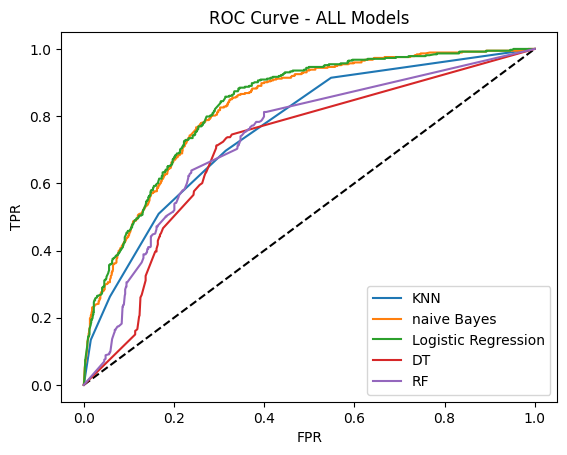

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

In [214]:
auc_roc(X_train, Y_train, X_test, Y_test)
plt.figure(figsize=(5,3))

In [215]:
#  We find hat Logistic Regression is the best model based on AUC-ROC curve

****Hyperparameter tuning Techniques****

In [216]:
reg = LogisticRegression(max_iter=1000)
reg.fit(X_train,Y_train)

print(f"Training accuracy : {accuracy_score(Y_train,reg.predict(X_train))}")
print(f"Test accuracy : {accuracy_score(Y_test,reg.predict(X_test))}")
print(f"Confusion matrix : {confusion_matrix(Y_test,reg.predict(X_test))}")
print(f"Classification report : {classification_report(Y_test,reg.predict(X_test))}")

Training accuracy : 0.7791977280795173
Test accuracy : 0.7849538679914834
Confusion matrix : [[935 101]
 [202 171]]
Classification report :               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.63      0.46      0.53       373

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [217]:
with open('customer-churn.pkl','wb') as f:
            pickle.dump(reg,f)

In [218]:
print(f"Training and saving the model completed")

Training and saving the model completed


In [219]:
#  load the model from file and check the model is working or not

In [220]:
with open('customer-churn.pkl','rb') as p:
            model = pickle.load(p)
with open('standard_scalar.pkl','rb') as p1:
            scal = pickle.load(p1)

In [221]:
import warnings
warnings.filterwarnings('ignore')

In [222]:
random_inputs = np.random.randint(0,1,10).ravel()
print(random_inputs.ndim)
random_inputs = random_inputs.reshape(1,-1)
scaled_random_inputs = scal.transform(random_inputs)
result_from_model = model.predict(scaled_random_inputs)
print(f"Model prediction : {result_from_model}")
if result_from_model[0] == 0:
    print(f"Not Churn")
else:
    print(f"Churn")

1
Model prediction : [1]
Churn


In [223]:
X_train.columns

Index(['tenure_yeo_trim', 'gender_Male', 'Partner_Yes', 'PhoneService_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [224]:
X_test.columns

Index(['tenure_yeo_trim', 'gender_Male', 'Partner_Yes', 'PhoneService_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [225]:
model

LogisticRegression(max_iter=1000)

In [226]:
print(model.feature_names_in_)

['tenure_yeo_trim' 'gender_Male' 'Partner_Yes' 'PhoneService_Yes'
 'Contract_One year' 'Contract_Two year' 'PaperlessBilling_Yes'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']
